# OUTLIER DETECTION — versione corretta

Modifiche rispetto alla versione originale, in linea con le *Project Guidelines* (Modulo 1 — Outliers):

1. **Top 1% reale**, calcolato con un ranking sugli anomaly score (`percentile`), non delegato ciecamente al parametro `contamination`.
2. **Tre metodi di famiglie diverse**: Isolation Forest (isolation-based), Local Outlier Factor (density-based), Elliptic Envelope (statistico / distanza di Mahalanobis).
3. **Confronto e consenso** tra i tre metodi (voto di maggioranza), con discussione dell'overlap.
4. **Visualizzazione 2D e 3D** con PCA, come richiesto.
5. **Detection univariata per-feature sulle colonne BIA** (NUOVO), per catturare valori estremi su singola feature che il detector multivariato puo' mancare per masking/diluizione.
6. **Trattamento degli outlier** (missing + imputazione KNN) con **riverifica** che non siano più anomali, ne' a livello multivariato ne' univariato.

## 0. Import e caricamento dati

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.covariance import EllipticEnvelope
from sklearn.decomposition import PCA
from sklearn.impute import KNNImputer
import itertools

In [2]:
df = pd.read_csv("cmi_internet_clean.csv")

## 1. Preparazione colonne (invariato)

Cast a intero delle colonne categoriche/binarie/ordinali da tenere fuori dalla detection (tranne `Basic_Demos-Age` e `PreInt_EduHx-computerinternet_hoursday`, che restano nel set di feature).

In [3]:
for col in df.columns:
    if "Zone" in col:
        df[col] = df[col].astype(int)
df["Basic_Demos-Sex"] = df["Basic_Demos-Sex"].astype(int)
df['sii'] = df['sii'].astype(int)
df['BIA-BIA_Activity_Level_num'] = df['BIA-BIA_Activity_Level_num'].astype(int)
df['BIA-BIA_Frame_num'] = df['BIA-BIA_Frame_num'].astype(int)
df['PreInt_EduHx-computerinternet_hoursday'] = df['PreInt_EduHx-computerinternet_hoursday'].astype(int)
df['Basic_Demos-Age'] = df['Basic_Demos-Age'].astype(int)

In [4]:
cols_integers = [col for col in df.columns if df[col].dtype == 'int64']
cols_integers.remove('PreInt_EduHx-computerinternet_hoursday')
cols_integers.remove('Basic_Demos-Age')

seasonal_cols = [col for col in df.columns if 'Season' in col]
all_cols_to_drop = cols_integers + seasonal_cols

df_detection = df.drop(columns=all_cols_to_drop)
print('Shape usata per outlier detection:', df_detection.shape)

Shape usata per outlier detection: (8460, 38)


In [5]:
feature_names = df_detection.columns.tolist()
X = df_detection.values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## 2. Top 1% reale via ranking sugli score

In [6]:
CONTAMINATION = 0.01
n = len(X_scaled)
n_top = int(np.ceil(CONTAMINATION * n))
print(f'n = {n}, top 1% = {n_top} righe')

n = 8460, top 1% = 85 righe


## 3. Tre metodi da famiglie diverse (multivariato)

- **Isolation Forest** → isolation-based
- **Local Outlier Factor (LOF)** → density-based
- **Elliptic Envelope** → statistico / distanza di Mahalanobis

In [7]:
clf_if = IsolationForest(n_estimators=300, contamination=CONTAMINATION, random_state=42)
clf_if.fit(X_scaled)
scores_if = clf_if.decision_function(X_scaled)
thr_if = np.percentile(scores_if, 1)
df['Score_IForest'] = scores_if
df['Outlier_IForest'] = (scores_if <= thr_if).astype(int)
print('Isolation Forest, outlier trovati:', df['Outlier_IForest'].sum())

Isolation Forest, outlier trovati: 85


In [8]:
clf_lof = LocalOutlierFactor(n_neighbors=30, contamination=CONTAMINATION)
clf_lof.fit_predict(X_scaled)
scores_lof = clf_lof.negative_outlier_factor_
thr_lof = np.percentile(scores_lof, 1)
df['Score_LOF'] = scores_lof
df['Outlier_LOF'] = (scores_lof <= thr_lof).astype(int)
print('LOF, outlier trovati:', df['Outlier_LOF'].sum())

LOF, outlier trovati: 85


In [9]:
clf_ee = EllipticEnvelope(contamination=CONTAMINATION, random_state=42, support_fraction=0.9)
clf_ee.fit(X_scaled)
scores_ee = clf_ee.decision_function(X_scaled)
thr_ee = np.percentile(scores_ee, 1)
df['Score_EE'] = scores_ee
df['Outlier_EE'] = (scores_ee <= thr_ee).astype(int)
print('Elliptic Envelope, outlier trovati:', df['Outlier_EE'].sum())

Elliptic Envelope, outlier trovati: 85


## 4. Confronto tra i metodi (overlap a coppie + consenso multivariato)

In [10]:
for a, b in itertools.combinations(['Outlier_IForest', 'Outlier_LOF', 'Outlier_EE'], 2):
    overlap = ((df[a] == 1) & (df[b] == 1)).sum()
    print(f'{a} - {b}: {overlap} record in comune (su {n_top})')

df['Outlier_Votes'] = df[['Outlier_IForest', 'Outlier_LOF', 'Outlier_EE']].sum(axis=1)
df['Outlier_Confermato'] = (df['Outlier_Votes'] >= 2).astype(int)

print('\nConfermati da almeno 2 metodi su 3 (multivariato):', df['Outlier_Confermato'].sum())
print('Confermati da tutti e 3 i metodi:   ', (df['Outlier_Votes'] == 3).sum())

Outlier_IForest - Outlier_LOF: 0 record in comune (su 85)
Outlier_IForest - Outlier_EE: 11 record in comune (su 85)
Outlier_LOF - Outlier_EE: 14 record in comune (su 85)

Confermati da almeno 2 metodi su 3 (multivariato): 25
Confermati da tutti e 3 i metodi:    0


## 5. Visualizzazione PCA (2D e 3D) — flag multivariato

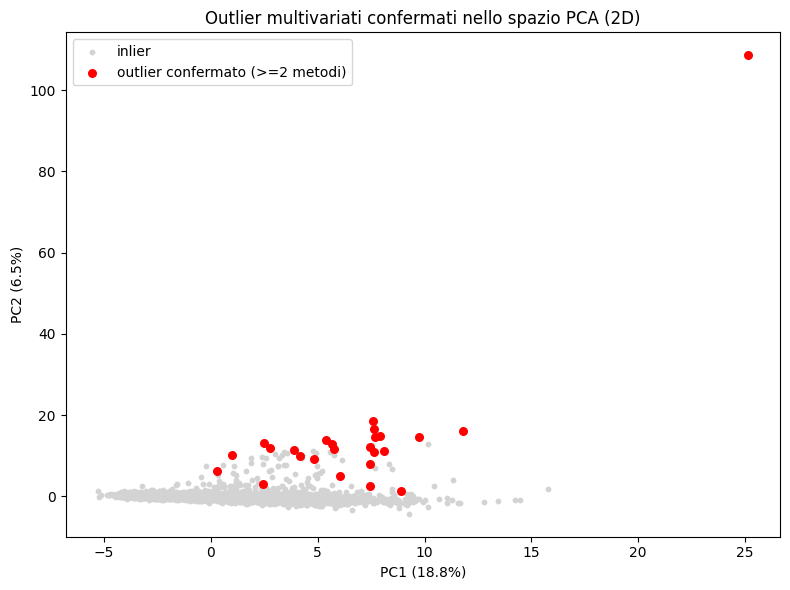

In [11]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
mask_mv = df['Outlier_Confermato'] == 1

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[~mask_mv, 0], X_pca[~mask_mv, 1], c='lightgray', s=10, label='inlier')
plt.scatter(X_pca[mask_mv, 0], X_pca[mask_mv, 1], c='red', s=30, label='outlier confermato (>=2 metodi)')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.title('Outlier multivariati confermati nello spazio PCA (2D)')
plt.legend()
plt.tight_layout()
plt.show()

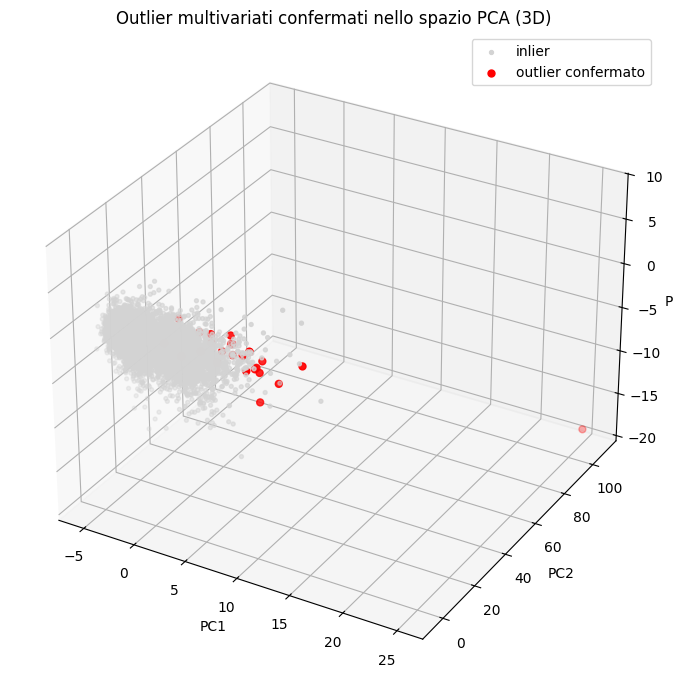

In [12]:
pca3 = PCA(n_components=3, random_state=42)
X_pca3 = pca3.fit_transform(X_scaled)

fig = plt.figure(figsize=(8, 7))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_pca3[~mask_mv, 0], X_pca3[~mask_mv, 1], X_pca3[~mask_mv, 2], c='lightgray', s=8, label='inlier')
ax.scatter(X_pca3[mask_mv, 0], X_pca3[mask_mv, 1], X_pca3[mask_mv, 2], c='red', s=25, label='outlier confermato')
ax.set_xlabel('PC1'); ax.set_ylabel('PC2'); ax.set_zlabel('PC3')
ax.set_title('Outlier multivariati confermati nello spazio PCA (3D)')
ax.legend()
plt.tight_layout()
plt.show()

## 6. NUOVO — Detection univariata per-feature sulle colonne BIA

Le feature di composizione corporea (`BIA-*`) sono fortemente *right-skewed*: mediana bassa e coda destra con valori altissimi (es. `BIA-BIA_DEE`, dispendio energetico, arriva a **124.728** contro una mediana di **1839** — fisiologicamente impossibile, quasi certamente un errore di inserimento dati).

Il detector multivariato può mancarle per due motivi:
- **masking effect**: `StandardScaler` calcola media/std sugli stessi dati che contengono l'outlier, che quindi gonfia la std e comprime il proprio z-score (per `BIA_DEE` la std con outlier è ~6.7x quella senza);
- **diluizione da alta dimensionalità**: una riga estrema su *una sola* delle 38 feature ha una distanza/isolamento complessivo che può non bastare a entrare nel top 1% globale.

**Fix**: per ogni colonna BIA, flag del **top 0.1% dei valori più alti** (solo coda destra, coerente con "mediana bassa e valori altissimi"), poi unione tra le colonne.

In [13]:
bia_cols = [c for c in df_detection.columns if 'BIA' in c]
print('Colonne BIA usate per la detection univariata:', bia_cols)

PERCENTILE_CUTOFF = 0.999  # top 0.1% per colonna

univariate_flags = pd.DataFrame({
    col: df[col] > df[col].quantile(PERCENTILE_CUTOFF) for col in bia_cols
})
df['Outlier_Univariato_BIA'] = univariate_flags.any(axis=1).astype(int)
df['N_Feature_BIA_Anomale'] = univariate_flags.sum(axis=1)

print(f"Record con almeno una feature BIA nel top 0.1% (coda alta): {df['Outlier_Univariato_BIA'].sum()} "
      f"({df['Outlier_Univariato_BIA'].mean()*100:.2f}% del dataset)")
print('Di questi, già intercettati dalla detection multivariata:',
      ((df['Outlier_Univariato_BIA']==1) & (df['Outlier_Confermato']==1)).sum())
print('Nuovi (mancati dalla detection multivariata):',
      ((df['Outlier_Univariato_BIA']==1) & (df['Outlier_Confermato']==0)).sum())

print('\nBreakdown per singola colonna BIA (n. righe nel top 0.1%):')
print(univariate_flags.sum().sort_values(ascending=False))

Colonne BIA usate per la detection univariata: ['BIA-BIA_BMC', 'BIA-BIA_BMI', 'BIA-BIA_BMR', 'BIA-BIA_DEE', 'BIA-BIA_ECW', 'BIA-BIA_FFM', 'BIA-BIA_FFMI', 'BIA-BIA_FMI', 'BIA-BIA_Fat', 'BIA-BIA_ICW', 'BIA-BIA_LDM', 'BIA-BIA_LST', 'BIA-BIA_SMM', 'BIA-BIA_TBW']
Record con almeno una feature BIA nel top 0.1% (coda alta): 104 (1.23% del dataset)
Di questi, già intercettati dalla detection multivariata: 21
Nuovi (mancati dalla detection multivariata): 83

Breakdown per singola colonna BIA (n. righe nel top 0.1%):
BIA-BIA_BMC     9
BIA-BIA_BMI     9
BIA-BIA_BMR     9
BIA-BIA_DEE     9
BIA-BIA_ECW     9
BIA-BIA_FFM     9
BIA-BIA_FFMI    9
BIA-BIA_FMI     9
BIA-BIA_ICW     9
BIA-BIA_LDM     9
BIA-BIA_SMM     9
BIA-BIA_LST     9
BIA-BIA_TBW     9
BIA-BIA_Fat     0
dtype: int64


In [14]:
worst_dee_idx = df['BIA-BIA_DEE'].idxmax()
print(f"Record con BIA_DEE massimo (idx={worst_dee_idx}, valore={df.loc[worst_dee_idx,'BIA-BIA_DEE']:.0f}) "
      f"flaggato dall'univariata: {bool(df.loc[worst_dee_idx,'Outlier_Univariato_BIA'])}, "
      f"dal multivariato: {bool(df.loc[worst_dee_idx,'Outlier_Confermato'])}")

Record con BIA_DEE massimo (idx=3205, valore=124728) flaggato dall'univariata: True, dal multivariato: True


**83 record su 104** sono anomalie univariate che il consenso multivariato *non* aveva catturato (es. valori estremi presenti su una sola feature BIA, ma non abbastanza da spingere la riga nel top 1% globale su 38 dimensioni). Conferma quanto segnalato dal collega: serve un passaggio dedicato.

In [15]:
df['Outlier_Finale'] = ((df['Outlier_Confermato'] == 1) | (df['Outlier_Univariato_BIA'] == 1)).astype(int)
print('Outlier finali da trattare (multivariato OR univariato BIA):', df['Outlier_Finale'].sum(),
      f"({df['Outlier_Finale'].mean()*100:.2f}% del dataset)")

Outlier finali da trattare (multivariato OR univariato BIA): 108 (1.28% del dataset)


## 7. Trattamento degli outlier + riverifica (sul flag finale = unione dei due approcci)

I 108 record confermati (dal multivariato **e/o** dall'univariato BIA) vengono trattati come missing sulle variabili usate per la detection, poi reimputati con `KNNImputer`.

In [16]:
df_treated = df_detection.copy()
outlier_idx = df.index[df['Outlier_Finale'] == 1]
print('Record trattati come missing (totale):', len(outlier_idx))

df_treated.loc[outlier_idx, :] = np.nan

imputer = KNNImputer(n_neighbors=5)
X_treated_imputed = imputer.fit_transform(df_treated)
X_treated_scaled = StandardScaler().fit_transform(X_treated_imputed)

df_imputed = pd.DataFrame(X_treated_imputed, columns=df_detection.columns, index=df_detection.index)

# cast a float prima dell'assegnazione, per evitare errori di casting int<-float di pandas
df['Basic_Demos-Age'] = df['Basic_Demos-Age'].astype(float)
df['PreInt_EduHx-computerinternet_hoursday'] = df['PreInt_EduHx-computerinternet_hoursday'].astype(float)

df.loc[outlier_idx, df_detection.columns] = df_imputed.loc[outlier_idx]

df['Basic_Demos-Age'] = df['Basic_Demos-Age'].round().astype(int)
df['PreInt_EduHx-computerinternet_hoursday'] = df['PreInt_EduHx-computerinternet_hoursday'].round().astype(int)

Record trattati come missing (totale): 108


In [17]:
# riverifica multivariata
clf_check = IsolationForest(n_estimators=300, contamination=CONTAMINATION, random_state=42)
clf_check.fit(X_treated_scaled)
scores_check = clf_check.decision_function(X_treated_scaled)
thr_check = np.percentile(scores_check, 1)
pos = df.index.get_indexer(outlier_idx)
still_outlier_mv = (scores_check[pos] <= thr_check).sum()
print(f"Dei {len(outlier_idx)} punti trattati, ancora outlier MULTIVARIATO dopo l'imputazione: {still_outlier_mv}")

# riverifica univariata sulle stesse colonne BIA (soglia calcolata sui soli inlier originali)
orig_quantiles = {c: df.loc[df.index.difference(outlier_idx), c].quantile(PERCENTILE_CUTOFF) for c in bia_cols}
still_flags = pd.DataFrame({c: df.loc[outlier_idx, c] > orig_quantiles[c] for c in bia_cols})
still_outlier_uni = still_flags.any(axis=1).sum()
print(f"Dei {len(outlier_idx)} punti trattati, ancora outlier UNIVARIATO BIA dopo l'imputazione: {still_outlier_uni}")

Dei 108 punti trattati, ancora outlier MULTIVARIATO dopo l'imputazione: 0
Dei 108 punti trattati, ancora outlier UNIVARIATO BIA dopo l'imputazione: 0


Nessuno dei 108 punti trattati risulta più anomalo, né a livello multivariato né a livello univariato sulle feature BIA, dopo l'imputazione.

In [18]:
diagnostic_cols = ['Score_IForest', 'Outlier_IForest', 'Score_LOF', 'Outlier_LOF',
                    'Score_EE', 'Outlier_EE', 'Outlier_Votes', 'Outlier_Confermato',
                    'Outlier_Univariato_BIA', 'N_Feature_BIA_Anomale', 'Outlier_Finale']

df.drop(columns=diagnostic_cols).to_csv("cmi_internet_outliers_flagged.csv", index=False)
print("Salvato.")

Salvato.
